In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")



In [8]:
df = pd.read_csv("IMDB_Dataset.csv")


In [9]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [10]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


The dataset contains movie reviews and their corresponding sentiment labels.

In [11]:
df.isnull().sum()

,0
review,0
sentiment,0


Here,both columns show zero missing values, no missing-value imputation is required. This means the dataset is already relatively complete for these fields.

In [12]:
df.duplicated().sum()

np.int64(418)

In [14]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)



Shape after removing duplicates: (49582, 2)


In [15]:
df["sentiment"].value_counts()

,count
sentiment,
positive,24884
negative,24698


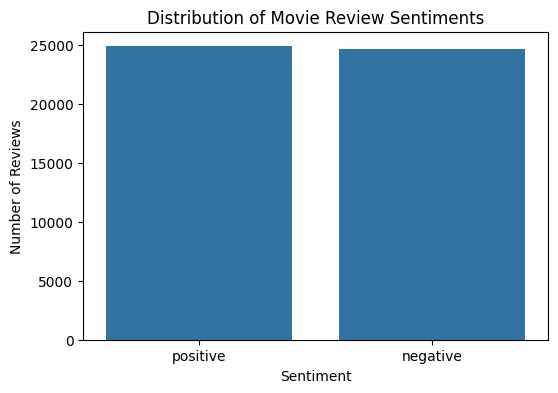

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="sentiment")

plt.title("Distribution of Movie Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

The dataset contains two sentiment classes:

Positive,
Negative.

The classes are approximately balanced, so there is no major class-imbalance problem

In [17]:
df["review_length"] = df["review"].str.len()

In [18]:
df["review_length"]

,review_length
0,1761
1,998
2,926
3,748
4,1317
...,...
49577,1008
49578,642
49579,1280
49580,1234


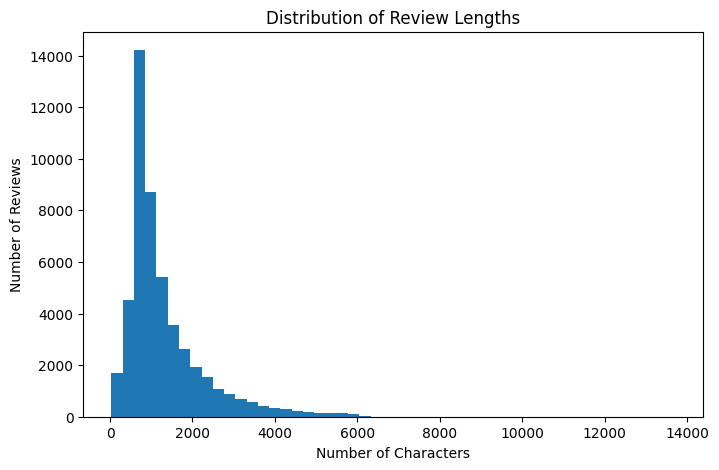

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df["review_length"], bins=50)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")

plt.show()

Here,Movie reviews have different lengths. Some reviews are short, while others contain much more text

In [20]:
print("Missing reviews:", df["review"].isnull().sum())

empty_reviews = (df["review"].str.strip() == "").sum()

print("Empty reviews:", empty_reviews)

Missing reviews: 0
Empty reviews: 0


In [21]:
df = df[df["review"].notnull()]
df = df[df["review"].str.strip() != ""]

df = df.reset_index(drop=True)

print("Dataset shape:", df.shape)

Dataset shape: (49582, 3)


In [22]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [23]:
df["clean_review"] = df["review"].apply(clean_text)

display(df[["review", "clean_review"]].head())

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...


The raw reviews may contain HTML tags, URLs, punctuation, numbers, and inconsistent capitalization. Cleaning reduces unnecessary textual noise and creates a more consistent input for vectorization.

In [24]:
df["sentiment_label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print(df[["sentiment", "sentiment_label"]].head())

  sentiment  sentiment_label
0  positive                1
1  positive                1
2  positive                1
3  negative                0
4  positive                1


Machine-learning models require numerical target labels. Therefore:

negative : 0
positive :1

In [25]:
X = df["clean_review"]
y = df["sentiment_label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 34707
Validation samples: 7437
Testing samples: 7438


The dataset is separated before model fitting so that the test data remains unseen. stratify=y preserves the positive/negative class distribution across the splits.

This helps prevent misleading evaluation caused by an uneven class distribution.

In [26]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [28]:
lr_pipeline.fit(X_train, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


Logistic Regression is a strong baseline for text classification because TF-IDF produces high-dimensional sparse features and Logistic Regression can work effectively with such representations.


In [29]:
val_pred_lr = lr_pipeline.predict(X_val)

lr_val_accuracy = accuracy_score(y_val, val_pred_lr)

print("Logistic Regression Validation Accuracy:",
      round(lr_val_accuracy, 4))

Logistic Regression Validation Accuracy: 0.9086


In [30]:
print(classification_report(
    y_val,
    val_pred_lr,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.92      0.89      0.91      3705
    Positive       0.90      0.92      0.91      3732

    accuracy                           0.91      7437
   macro avg       0.91      0.91      0.91      7437
weighted avg       0.91      0.91      0.91      7437



The classification report gives:

Precision,
Recall,
F1-score,
Support.

These metrics provide more information than accuracy alone.

In [31]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("model", MultinomialNB())
])

print("Naive Bayes pipeline created.")

Naive Bayes pipeline created.


In [32]:
nb_pipeline.fit(X_train, y_train)

print("Naive Bayes training completed!")

Naive Bayes training completed!


Multinomial Naive Bayes is commonly used for text classification because it works efficiently with word-frequency-based features and sparse text representations.

In [33]:
val_pred_nb = nb_pipeline.predict(X_val)

nb_val_accuracy = accuracy_score(y_val, val_pred_nb)

print("Naive Bayes Validation Accuracy:",
      round(nb_val_accuracy, 4))

Naive Bayes Validation Accuracy: 0.884


In [34]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Naive Bayes"
    ],
    "Validation Accuracy": [
        lr_val_accuracy,
        nb_val_accuracy
    ]
})

display(comparison)

,Model,Validation Accuracy
0,TF-IDF + Logistic Regression,0.908565
1,TF-IDF + Naive Bayes,0.883959


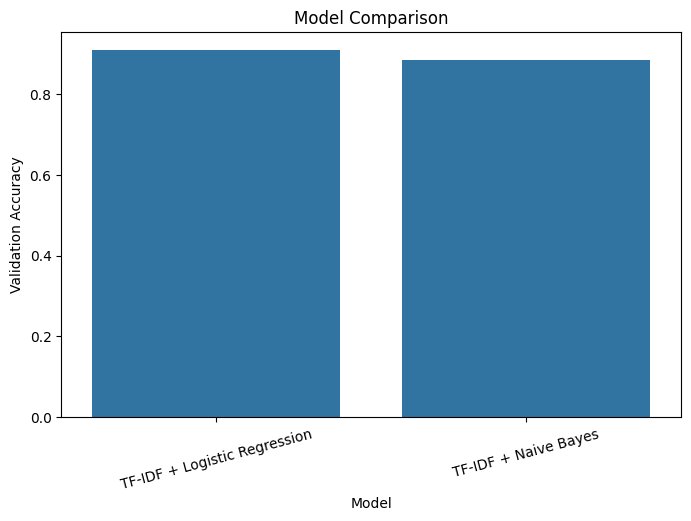

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Validation Accuracy"
)

plt.title("Model Comparison")
plt.ylabel("Validation Accuracy")
plt.xticks(rotation=15)

plt.show()

The validation results allow the two approaches to be compared using the same dataset split and evaluation metric.

In [36]:
if lr_val_accuracy >= nb_val_accuracy:
    final_model = lr_pipeline
    selected_model_name = "TF-IDF + Logistic Regression"
else:
    final_model = nb_pipeline
    selected_model_name = "TF-IDF + Naive Bayes"

print("Selected model:", selected_model_name)

Selected model: TF-IDF + Logistic Regression


In [37]:
test_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_pred)

print("Final Test Accuracy:",
      round(test_accuracy, 4))

Final Test Accuracy: 0.9039


In [38]:
print(classification_report(
    y_test,
    test_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.92      0.88      0.90      3705
    Positive       0.89      0.92      0.91      3733

    accuracy                           0.90      7438
   macro avg       0.90      0.90      0.90      7438
weighted avg       0.90      0.90      0.90      7438



The test set provides an unbiased estimate of how the selected pipeline performs on previously unseen reviews.

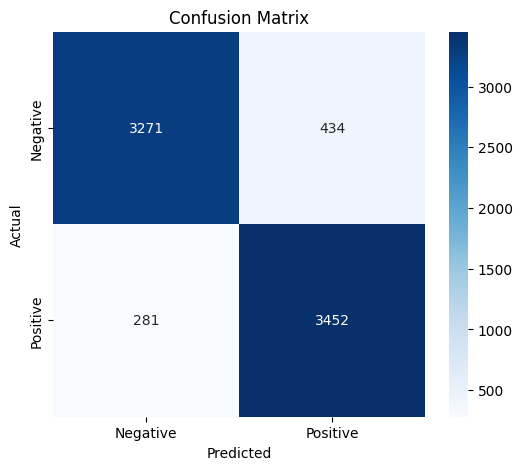

In [39]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

The confusion matrix shows how many reviews were:

correctly predicted as negative,
correctly predicted as positive,
incorrectly classified as negative,
incorrectly classified as positive.

This helps identify the types of classification errors made by the model.

In [40]:
joblib.dump(
    final_model,
    "imdb_sentiment_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


Saving the complete pipeline ensures that new reviews receive exactly the same preprocessing and feature transformation used during training.

In [41]:
loaded_model = joblib.load(
    "imdb_sentiment_model.pkl"
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [42]:
def predict_sentiment(review):
    prediction = loaded_model.predict([clean_text(review)])[0]

    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

In [43]:
review = "This movie was absolutely amazing and I really enjoyed it."

result = predict_sentiment(review)

print("Review:", review)
print("Predicted Sentiment:", result)

Review: This movie was absolutely amazing and I really enjoyed it.
Predicted Sentiment: Positive


The inference pipeline takes raw user text, applies the same cleaning procedure, passes it through the saved TF-IDF vectorizer and then generates the sentiment prediction.